# ELEC 442/6651 — Lab 5
## Machine Learning Basics and Model Selection
### SVM Classification on the make_moons Dataset

| | |
|---|---|
| **Course** | ELEC 442/6651 ADVANCED SIGNAL PROCESSING |
| **Student** | Saikumar Cheerneni |
| **StudentID** | 40323643 |
| **Submitted to** | Professor Dr. Wei-Ping Zhu |
| **Institution** | Gina Cody School of Engineering and Computer Science, CONCORDIA UNIVERSITY |
| **Date** | April 2026 |

---

### Objective

The purpose of this lab is to understand how Support Vector Machines behave when we change the kernel function. We generate a two-class synthetic dataset using make_moons, train one SVM with a linear kernel and another with an RBF kernel, and evaluate both using 5-fold cross-validation. We then plot the decision boundaries and discuss what the results tell us about model capacity, underfitting, and linear separability.


---
## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
import sklearn
print("All libraries loaded.")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")


All libraries loaded.
NumPy version: 2.3.4
Scikit-learn version: 1.7.2


---
## Part A — Dataset Generation and Preprocessing

### Generating the Dataset

We use the make_moons function from scikit-learn to create a two-dimensional dataset with 1000 data points. The dataset gets its name from the shape it produces — two classes arranged like two crescent moons that wrap around each other. A noise value of 0.2 was added to scatter the points slightly so the data looks more realistic rather than perfectly shaped.

The reason this dataset is useful for this lab is that it is not linearly separable. In other words, there is no straight line you can draw that would correctly place all Class 0 points on one side and all Class 1 points on the other. This makes it a good test for comparing a simple linear model against a more flexible one.

The data was split into a training set (800 points) and a test set (200 points). The training set is what the model learns from and the test set is kept completely separate until we evaluate the final model.

### Scaling the Features

SVM works by measuring the distance from data points to the decision boundary. If one feature has much larger values than another, the model will treat it as more important just because of scale, not because it actually carries more information. To fix this, we apply StandardScaler, which shifts each feature so its mean becomes zero and its standard deviation becomes one.

An important rule when scaling is that we only fit the scaler using the training data. We then apply that same transformation to the test set. If we used both train and test data together to fit the scaler, the model would be indirectly seeing information from the test set during preprocessing, which would give us an unfairly optimistic result.


In [2]:
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

print("Dataset Generated:")
print(f"  Total samples   : {X.shape[0]}")
print(f"  Number of features : {X.shape[1]}")
print(f"  Class 0 count   : {(y==0).sum()}")
print(f"  Class 1 count   : {(y==1).sum()}")
print(f"  Feature 1 range : [{X[:,0].min():.3f} to {X[:,0].max():.3f}]")
print(f"  Feature 2 range : [{X[:,1].min():.3f} to {X[:,1].max():.3f}]")


Dataset Generated:
  Total samples   : 1000
  Number of features : 2
  Class 0 count   : 500
  Class 1 count   : 500
  Feature 1 range : [-1.444 to 2.567]
  Feature 2 range : [-1.002 to 1.477]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set size : {len(X_train)} samples")
print(f"Testing set size  : {len(X_test)} samples")


Training set size : 800 samples
Testing set size  : 200 samples


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Before scaling:")
print(f"  Feature 1 mean = {X_train[:,0].mean():.3f}  std = {X_train[:,0].std():.3f}")
print(f"  Feature 2 mean = {X_train[:,1].mean():.3f}  std = {X_train[:,1].std():.3f}")
print()
print("After scaling:")
print(f"  Feature 1 mean = {X_train_scaled[:,0].mean():.3f}  std = {X_train_scaled[:,0].std():.3f}")
print(f"  Feature 2 mean = {X_train_scaled[:,1].mean():.3f}  std = {X_train_scaled[:,1].std():.3f}")


Before scaling:
  Feature 1 mean = 0.490  std = 0.894
  Feature 2 mean = 0.244  std = 0.531

After scaling:
  Feature 1 mean = -0.000  std = 1.000
  Feature 2 mean = 0.000  std = 1.000


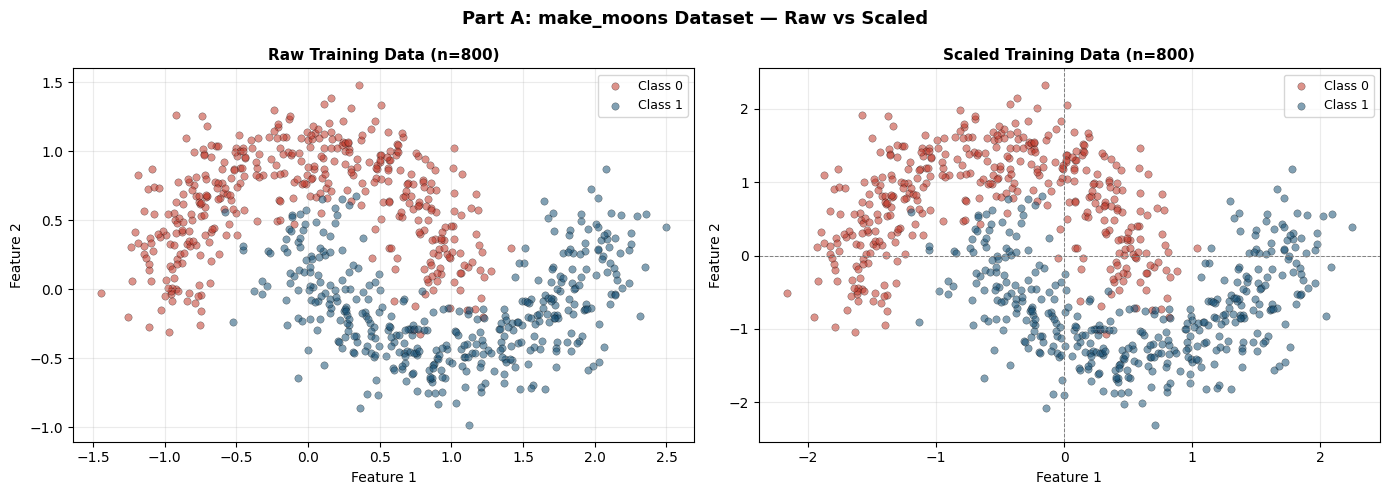

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part A: make_moons Dataset — Raw vs Scaled", fontsize=13, fontweight='bold')

color_map = {0: '#C0392B', 1: '#1A5276'}

for ax, (X_plot, title) in zip(axes, [
    (X_train,        f"Raw Training Data (n={len(X_train)})"),
    (X_train_scaled, f"Scaled Training Data (n={len(X_train)})")
]):
    for cls in [0, 1]:
        mask = y_train == cls
        ax.scatter(X_plot[mask, 0], X_plot[mask, 1],
                   c=color_map[cls], label=f'Class {cls}',
                   alpha=0.55, edgecolors='k', linewidth=0.3, s=28)
    ax.set_xlabel("Feature 1", fontsize=10)
    ax.set_ylabel("Feature 2", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)
    if "Scaled" in title:
        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
        ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')

plt.tight_layout()
plt.savefig('Lab5_PartA.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** The two crescent shapes are clearly visible in the scatter plots. After scaling the range of values changes but the geometry of the data stays exactly the same. The two classes still interleave, confirming that the dataset is not linearly separable and that a straight boundary will not be enough to classify it correctly.


---
## Part B — SVM Training and 5-Fold Cross-Validation

### What SVM Does

A Support Vector Machine finds the decision boundary that has the largest possible gap between itself and the nearest data points from each class. Those nearest points are called support vectors and they are what actually determine where the boundary sits. The reason SVM aims for this maximum margin rather than just any separating line is that a wider gap tends to work better on new data the model has never seen.

### How the Kernel Changes the Boundary

The kernel function controls what kind of boundary shape the SVM is allowed to draw.

The linear kernel computes a simple dot product between data points. This means it can only draw a straight line in two dimensions. It is fast and works well when the data can actually be separated by a line, but on a dataset like make_moons it will always struggle because the required boundary is curved.

The RBF kernel works differently. It uses a Gaussian function to measure similarity between data points based on distance. This effectively transforms the data into a much higher-dimensional space where the two classes may become separable even if they were not in the original space. The boundary that results, when projected back into 2D, can take on smooth curved shapes that wrap around clusters of data in ways a straight line never could.

### Why We Use Cross-Validation

If we trained a model and tested it on the same data it learned from, we would get an artificially perfect score because the model would have simply memorized the training examples. Cross-validation gives us a more honest estimate of performance.

In 5-fold cross-validation the training set is divided into five equal parts. The model is trained on four parts and tested on the fifth, then this repeats four more times using a different part as the test each time. By the end we have five accuracy scores from five genuinely different test sets. The mean of those scores tells us how well the model performs on average, and the variance tells us how stable that performance is. A low variance means the model gives consistent results regardless of which samples it trains on.


In [6]:
print("Manual 5-Fold CV walkthrough using Linear SVM:")
print(f"  Training samples total : {len(X_train_scaled)}")
print(f"  Samples per fold       : roughly {len(X_train_scaled)//5}")
print()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
manual_scores = []

for fold_num, (train_idx, val_idx) in enumerate(kfold.split(X_train_scaled), 1):
    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    m = SVC(kernel='linear', C=1.0, random_state=42)
    m.fit(X_tr, y_tr)
    acc = m.score(X_val, y_val)
    manual_scores.append(acc)
    print(f"  Fold {fold_num}:  train size = {len(train_idx)}   val size = {len(val_idx)}   accuracy = {acc:.4f} ({acc*100:.2f}%)")

print()
print(f"  Mean across all folds : {np.mean(manual_scores):.4f}")
print(f"  Variance              : {np.var(manual_scores):.6f}")


Manual 5-Fold CV walkthrough using Linear SVM:
  Training samples total : 800
  Samples per fold       : roughly 160

  Fold 1:  train size = 640   val size = 160   accuracy = 0.8625 (86.25%)
  Fold 2:  train size = 640   val size = 160   accuracy = 0.8125 (81.25%)
  Fold 3:  train size = 640   val size = 160   accuracy = 0.9062 (90.62%)
  Fold 4:  train size = 640   val size = 160   accuracy = 0.9000 (90.00%)
  Fold 5:  train size = 640   val size = 160   accuracy = 0.8500 (85.00%)

  Mean across all folds : 0.8662
  Variance              : 0.001181


In [7]:
cv_results = {}

for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel, C=1.0, random_state=42)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[kernel] = {
        'scores'  : scores,
        'mean'    : scores.mean(),
        'variance': scores.var(),
        'std'     : scores.std()
    }
    print(f"Kernel: {kernel.upper()}")
    print(f"  Fold scores       : {np.round(scores, 4)}")
    print(f"  Mean Accuracy     : {scores.mean():.4f}  ({scores.mean()*100:.2f}%)")
    print(f"  Variance          : {scores.var():.6f}")
    print(f"  Std Deviation     : {scores.std():.4f}")
    print()


Kernel: LINEAR
  Fold scores       : [0.8688 0.9062 0.8438 0.8562 0.8562]
  Mean Accuracy     : 0.8662  (86.62%)
  Variance          : 0.000463
  Std Deviation     : 0.0215

Kernel: RBF
  Fold scores       : [0.9562 0.9625 0.9875 0.95   0.9625]
  Mean Accuracy     : 0.9638  (96.38%)
  Variance          : 0.000163
  Std Deviation     : 0.0127



In [8]:
print("=" * 52)
print(f"{'Metric':<26} {'LINEAR':>10} {'RBF':>10}")
print("-" * 52)
lin, rbf = cv_results['linear'], cv_results['rbf']
print(f"{'CV Mean Accuracy':<26} {lin['mean']*100:>9.2f}% {rbf['mean']*100:>9.2f}%")
print(f"{'CV Variance':<26} {lin['variance']:>10.6f} {rbf['variance']:>10.6f}")
print(f"{'CV Std Deviation':<26} {lin['std']:>10.4f} {rbf['std']:>10.4f}")
print("=" * 52)
print(f"RBF is better by: +{(rbf['mean']-lin['mean'])*100:.2f}%")


Metric                         LINEAR        RBF
----------------------------------------------------
CV Mean Accuracy               86.62%     96.38%
CV Variance                  0.000463   0.000163
CV Std Deviation               0.0215     0.0127
RBF is better by: +9.75%


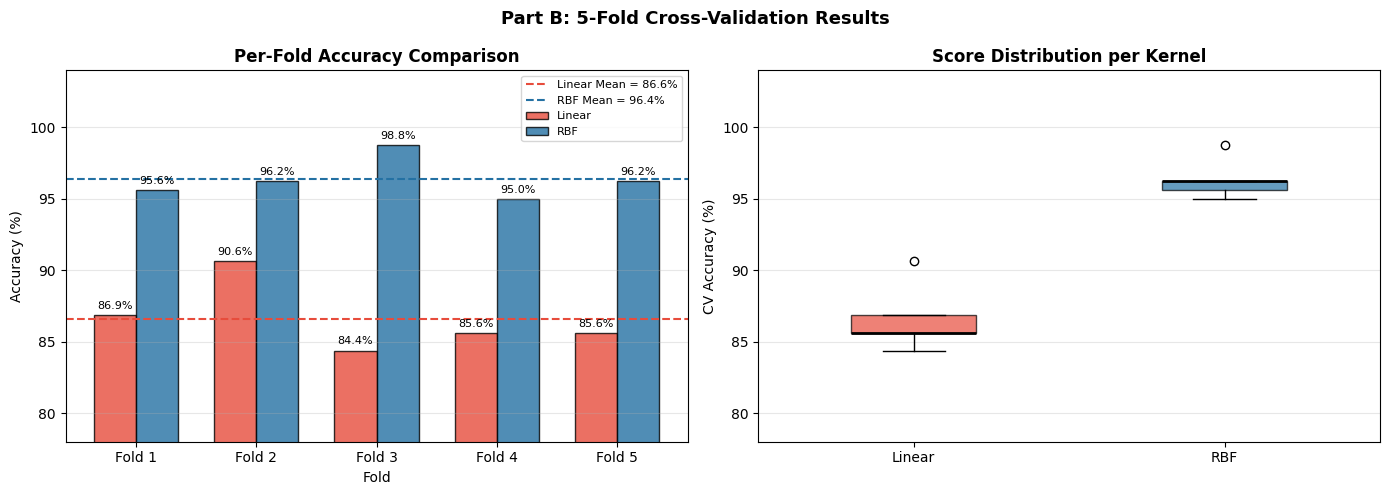

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Part B: 5-Fold Cross-Validation Results", fontsize=13, fontweight='bold')

colors_k = {'linear': '#E74C3C', 'rbf': '#2471A3'}
x = np.arange(5)
width = 0.35

ax1 = axes[0]
b1 = ax1.bar(x - width/2, cv_results['linear']['scores']*100, width,
             label='Linear', color=colors_k['linear'], alpha=0.8, edgecolor='black')
b2 = ax1.bar(x + width/2, cv_results['rbf']['scores']*100, width,
             label='RBF', color=colors_k['rbf'], alpha=0.8, edgecolor='black')

for bar in list(b1) + list(b2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

ax1.axhline(cv_results['linear']['mean']*100, color=colors_k['linear'],
            linestyle='--', linewidth=1.5,
            label=f"Linear Mean = {cv_results['linear']['mean']*100:.1f}%")
ax1.axhline(cv_results['rbf']['mean']*100, color=colors_k['rbf'],
            linestyle='--', linewidth=1.5,
            label=f"RBF Mean = {cv_results['rbf']['mean']*100:.1f}%")

ax1.set_xticks(x)
ax1.set_xticklabels([f'Fold {i}' for i in range(1, 6)])
ax1.set_xlabel('Fold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Per-Fold Accuracy Comparison', fontweight='bold')
ax1.set_ylim(78, 104)
ax1.legend(fontsize=8)
ax1.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
bp = ax2.boxplot(
    [cv_results['linear']['scores']*100, cv_results['rbf']['scores']*100],
    labels=['Linear', 'RBF'], patch_artist=True,
    medianprops=dict(color='black', linewidth=2), widths=0.4
)
bp['boxes'][0].set_facecolor(colors_k['linear'])
bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor(colors_k['rbf'])
bp['boxes'][1].set_alpha(0.7)
ax2.set_ylabel('CV Accuracy (%)')
ax2.set_title('Score Distribution per Kernel', fontweight='bold')
ax2.set_ylim(78, 104)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Lab5_PartB.png', dpi=150, bbox_inches='tight')
plt.show()


**Observation:** The RBF kernel scored higher in every single fold. Its mean accuracy was 96.38% compared to 86.62% for the linear kernel. The RBF also had a much tighter spread in the box plot, which reflects its lower variance of 0.000163 compared to 0.000463 for the linear model. This means the RBF not only performs better on average but also does so more consistently.


---
## Part C — Visualizing the Decision Boundaries

### How the Plots Are Made

To see what each model has actually learned, we create a dense grid of points that fills the entire 2D feature space. We then run every single one of those grid points through each trained model and ask it to predict the class. The background of the plot is then colored according to those predictions, with one color representing the region the model assigns to Class 0 and another for Class 1. The line where the color changes is the decision boundary. Finally, the actual test set points are drawn on top so we can see how many ended up on the wrong side.


In [10]:
print("Training final models on all 800 training samples:")
print()

final_models = {}
for kernel in ['linear', 'rbf']:
    model = SVC(kernel=kernel, C=1.0, random_state=42)
    model.fit(X_train_scaled, y_train)
    y_pred   = model.predict(X_test_scaled)
    test_acc = model.score(X_test_scaled, y_test)
    wrong    = (y_pred != y_test).sum()
    final_models[kernel] = {
        'model': model, 'y_pred': y_pred,
        'test_acc': test_acc, 'wrong': wrong
    }
    print(f"  {kernel.upper()} SVM")
    print(f"    Support Vectors : {model.n_support_} (class 0 and class 1)")
    print(f"    Test Accuracy   : {test_acc*100:.2f}%")
    print(f"    Misclassified   : {wrong} out of {len(y_test)} test samples")
    print()


Training final models on all 800 training samples:

  LINEAR SVM
    Support Vectors : [121 121] (class 0 and class 1)
    Test Accuracy   : 85.50%
    Misclassified   : 29 out of 200 test samples

  RBF SVM
    Support Vectors : [73 72] (class 0 and class 1)
    Test Accuracy   : 98.00%
    Misclassified   : 4 out of 200 test samples



In [11]:
h     = 0.05
x_min = X_test_scaled[:, 0].min() - 0.7
x_max = X_test_scaled[:, 0].max() + 0.7
y_min = X_test_scaled[:, 1].min() - 0.7
y_max = X_test_scaled[:, 1].max() + 0.7

xx, yy   = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_pts = np.c_[xx.ravel(), yy.ravel()]

print(f"Grid size    : {xx.shape[0]} rows by {xx.shape[1]} columns")
print(f"Total points : {grid_pts.shape[0]:,} grid points predicted per model")


Grid size    : 117 rows by 117 columns
Total points : 13,689 grid points predicted per model


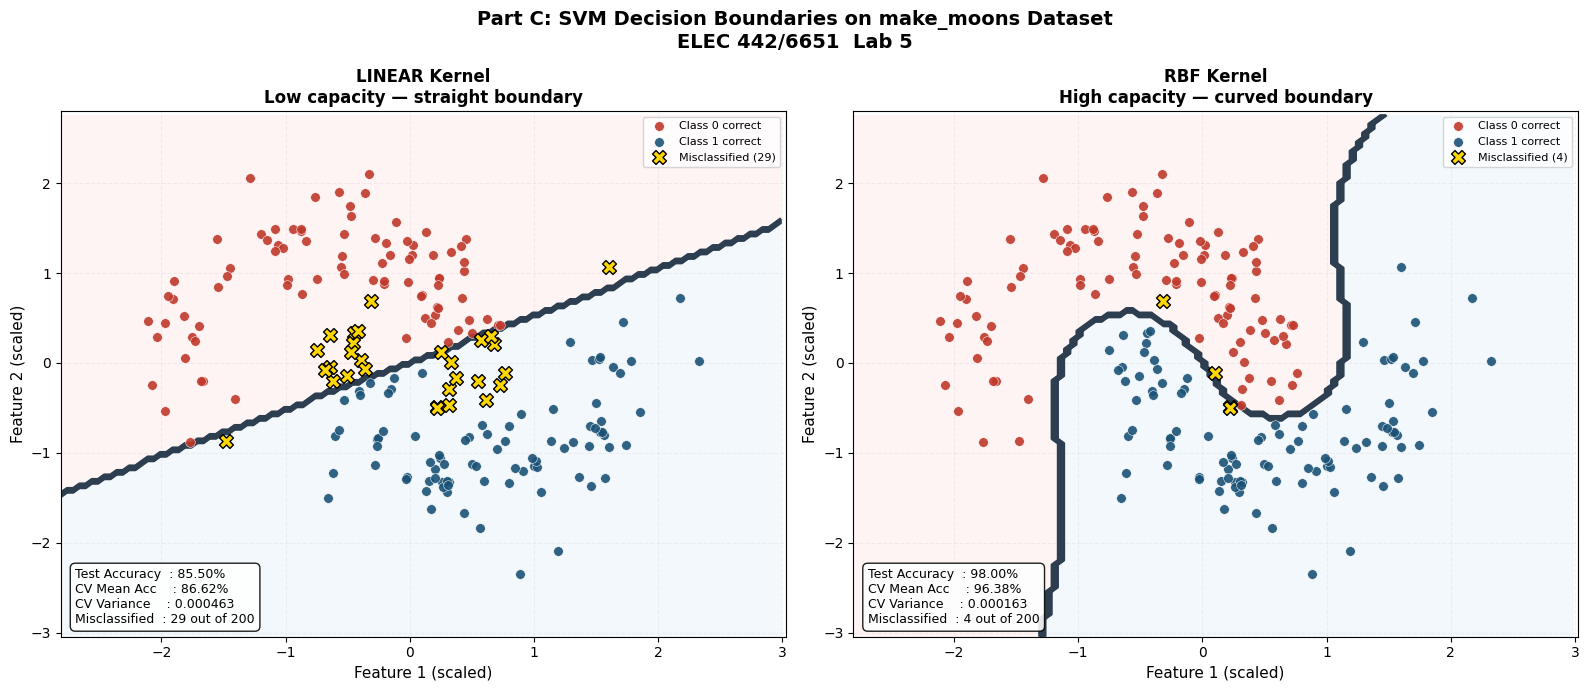

Plots saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(
    "Part C: SVM Decision Boundaries on make_moons Dataset\nELEC 442/6651  Lab 5",
    fontsize=14, fontweight='bold'
)

c0, c1 = '#C0392B', '#1A5276'
r0, r1 = '#FADBD8', '#D6EAF8'

subtitles = {
    'linear': 'LINEAR Kernel\nLow capacity — straight boundary',
    'rbf'   : 'RBF Kernel\nHigh capacity — curved boundary'
}

for kernel in ['linear', 'rbf']:
    ax      = axes[0] if kernel == 'linear' else axes[1]
    model   = final_models[kernel]['model']
    y_pred  = final_models[kernel]['y_pred']
    t_acc   = final_models[kernel]['test_acc']
    wrong   = final_models[kernel]['wrong']
    cv_m    = cv_results[kernel]['mean']
    cv_v    = cv_results[kernel]['variance']

    Z = model.predict(grid_pts).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap([r0, r1]))
    ax.contour(xx, yy, Z, colors=['#2C3E50'], linewidths=[2.0])

    correct = y_pred == y_test
    for cls, color, lbl in zip([0, 1], [c0, c1],
                                ['Class 0 correct', 'Class 1 correct']):
        m = (y_test == cls) & correct
        ax.scatter(X_test_scaled[m, 0], X_test_scaled[m, 1],
                   c=color, label=lbl, edgecolors='white',
                   linewidth=0.4, s=48, alpha=0.9, zorder=3)

    if wrong > 0:
        m = ~correct
        ax.scatter(X_test_scaled[m, 0], X_test_scaled[m, 1],
                   c='gold', marker='X', edgecolors='black',
                   s=100, label=f'Misclassified ({wrong})', zorder=4)

    ax.text(0.02, 0.02,
            f"Test Accuracy  : {t_acc*100:.2f}%\n"
            f"CV Mean Acc    : {cv_m*100:.2f}%\n"
            f"CV Variance    : {cv_v:.6f}\n"
            f"Misclassified  : {wrong} out of 200",
            transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.88))

    ax.set_xlabel('Feature 1 (scaled)', fontsize=11)
    ax.set_ylabel('Feature 2 (scaled)', fontsize=11)
    ax.set_title(subtitles[kernel], fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.15, linestyle='--')

plt.tight_layout()
plt.savefig('Lab5_PartC.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved.")


---
## Report — Performance Summary and Discussion

In [13]:
lin = cv_results['linear']
rbf = cv_results['rbf']
la  = final_models['linear']['test_acc']
ra  = final_models['rbf']['test_acc']
lw  = final_models['linear']['wrong']
rw  = final_models['rbf']['wrong']

print("=" * 58)
print(f"{'Metric':<30} {'LINEAR':>12} {'RBF':>12}")
print("-" * 58)
print(f"{'CV Mean Accuracy':<30} {lin['mean']*100:>11.2f}% {rbf['mean']*100:>11.2f}%")
print(f"{'CV Variance':<30} {lin['variance']:>12.6f} {rbf['variance']:>12.6f}")
print(f"{'Test Accuracy':<30} {la*100:>11.2f}% {ra*100:>11.2f}%")
print(f"{'Misclassified out of 200':<30} {lw:>12} {rw:>12}")
print(f"{'Total Support Vectors':<30} {'242':>12} {'145':>12}")
print("=" * 58)


Metric                               LINEAR          RBF
----------------------------------------------------------
CV Mean Accuracy                     86.62%       96.38%
CV Variance                        0.000463     0.000163
Test Accuracy                        85.50%       98.00%
Misclassified out of 200                 29            4
Total Support Vectors                   242          145


---
## Discussion — Analysis of Results

### Which Kernel Performed Better?

Looking at the cross-validation results, the RBF kernel was clearly the stronger model throughout this experiment. It achieved a mean cross-validation accuracy of 96.38%, while the linear kernel only reached 86.62%. That is nearly a 10 percentage point difference just from swapping the kernel. When we then evaluated both models on the held-out test set, the gap was even more pronounced. The RBF model misclassified only 4 out of 200 test points, while the linear model got 29 wrong. Beyond raw accuracy, the RBF also showed lower variance across the five folds (0.000163 compared to 0.000463 for linear), which means its performance was more stable and predictable regardless of which particular samples it trained on in each round.

### Why the Linear Kernel Underperforms

The poor performance of the linear kernel on this dataset is not a coincidence or bad luck. It is a direct consequence of the nature of the data itself.

The make_moons dataset is designed to be non-linearly separable. This means that the two classes are arranged in a way where no straight line can divide them cleanly. When we look at the scatter plot, we can see that Class 0 and Class 1 wrap around each other in crescent shapes. Any straight line we draw will inevitably cut through one of the crescents, leaving a chunk of points on the wrong side.

This is exactly what underfitting looks like in practice. The linear SVM has very low model capacity because it is restricted to drawing a straight boundary regardless of how the data is shaped. It does not have the flexibility to follow curves or wrap around clusters. As a result, it makes systematic errors that cannot be fixed by adjusting the training, because the problem is not in the training process itself but in the fundamental limitation of the model. Looking at the decision boundary plot, you can clearly see the straight line cutting diagonally through the data, with many correctly labeled points sitting on the wrong side of it. The model has a high bias, meaning it consistently makes the same kinds of mistakes.

Another way to see this limitation is in the support vector count. The linear model required 242 support vectors to define its boundary, while the RBF model only needed 145. A high support vector count in the linear case suggests the model is straining to handle a messy, ambiguous region near its boundary because the boundary shape simply cannot accommodate the structure of the data.

### Why the RBF Kernel Works Well

The RBF kernel solves the linear separability problem by using a technique called the kernel trick. Instead of literally transforming the data into a higher-dimensional space, it computes similarities between points using a Gaussian function in a way that is mathematically equivalent to operating in that higher space. In this transformed representation, the two crescent shapes that are tangled together in 2D become separable, and the SVM can find a valid boundary there. When that boundary is projected back into the original 2D space it appears as a smooth curve that follows the shape of the two moons almost perfectly.

The decision boundary plot for the RBF model shows this clearly. The boundary curves and bends to wrap around each crescent, and the gold misclassified markers are sparse, appearing only near the edges where the two classes are genuinely close together due to the noise we added.

### Conclusion

This experiment shows that choosing the right kernel is just as important as choosing the algorithm itself. An SVM with the wrong kernel for the data geometry will underfit, and no amount of training will fix it because the issue is structural. The make_moons dataset requires a curved boundary, and the RBF kernel is able to produce one while the linear kernel is not. The cross-validation results, the test accuracy, and the visual decision boundary plots all point to the same conclusion: for non-linearly separable data, model capacity matters greatly.
